In [23]:
import numpy as np
import math
from scipy.stats import t
from scipy.stats import erlang, expon
import matplotlib.pyplot as plt

In [2]:
seed = 30
rng = np.random.default_rng(seed)

In [3]:
def blocking_system(m, At, St, max_customers):
    # Initialize array containing the time remaining for the currently served customers
    servers = np.zeros(m)

    # Initialize amount of customers simulated, current time, and amount of blocked customers
    customers = 0
    t = 0
    blocked_customers = 0

    # Run an iteration for each customer arrival
    while(customers < max_customers):
        # Simulate a customer arriving by drawing the time since the last customer from the arrival pattern A(t)
        arrival_time = At
        # Update global time according to this new arrival
        t += arrival_time

        # Update time remaining for each currently serviced customer with this new time jump
        servers -= arrival_time
        # If any time remaining is now below or equal to zero, that customer has departed and the server is marked empty
        servers = np.clip(servers, a_min=0, a_max=None)

        # Get all servers which are now free
        mask = servers == 0
        if (np.sum(mask) == 0):
            # If no servers are free at the time of this arrival, the customer is blocked
            blocked_customers += 1
        else:
            # Else the customer is directed to the first free server
            for i in range(m):
                if (servers[i] == 0):
                    # The time for this service is then initialized by drawing from the distribution of service times S(t)
                    servers[i] = St
                    break
        
        customers += 1
    
    # Return the rate of blocked customers in this simulation
    return blocked_customers/max_customers

### Part 1

In [4]:
def analytical_blocked(m, mean_service_time, mean_arrival):
    A = mean_service_time*mean_arrival
    B = (A**m)/(math.factorial(m))
    temp = 0
    for i in range(m+1):
        temp += (A**i)/(math.factorial(i))
    return B/temp

In [5]:
def blocking_system_poisson(m, mean_service_time, mean_arrival, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = rng.exponential(mean_arrival)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.exponential(mean_service_time)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [6]:
blocking_system_poisson(m=10, mean_service_time=8, mean_arrival=1, max_customers=10_000, rng=rng)

0.1166

In [7]:
seed = 30
rng = np.random.default_rng(seed)

mean_arrival = 1
print(f'Arrival process as a Poisson process with mean={mean_arrival}')

print(f'Theoretical rate: {analytical_blocked(m=10, mean_service_time=8, mean_arrival=1)}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson(m=10, mean_service_time=8, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')
print(f'Confidence interval width: {conf2 - conf1}')

Arrival process as a Poisson process with mean=1
Theoretical rate: 0.12166106425295149
Estimated rate: 0.12254000000000001
Confidence interval: (0.11841895365280357, 0.12666104634719644)
Confidence interval width: 0.008242092694392869


### Part 2

In [8]:
def blocking_system_erlang(m, mean_service_time, k, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = erlang.rvs(a=k, scale=1/k)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.exponential(mean_service_time)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [9]:
blocking_system_erlang(m=10, mean_service_time=8, k=2, max_customers=10_000, rng=rng)

0.099

In [10]:
seed = 30
rng = np.random.default_rng(seed)

k = 2
print(f'Erlang distributed inter arrival times with k={k}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_erlang(m=10, mean_service_time=8, k=k, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Erlang distributed inter arrival times with k=2
Estimated rate: 0.09267
Confidence interval: (0.08900495631447472, 0.09633504368552528)


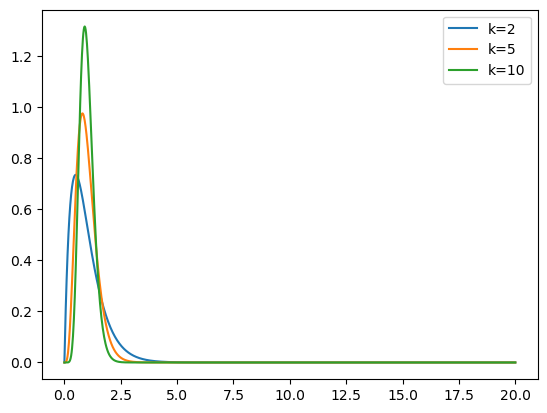

In [29]:
k = 2
x = np.linspace(0,20,1000)
y2 = erlang.pdf(x=x, a=k, scale=1/k)
k = 5
y5 = erlang.pdf(x=x, a=k, scale=1/k)
k = 10
y10 = erlang.pdf(x=x, a=k, scale=1/k)
plt.plot(x, y2, label='k=2')
plt.plot(x, y5, label='k=5')
plt.plot(x, y10, label='k=10')
plt.legend()
plt.show()

In [12]:
def blocking_system_hyperexponential(m, mean_service_time, p, lam, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        choice = rng.choice(a=[0,1], p=p)
        arrival_time = rng.exponential(1/lam[choice])
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.exponential(mean_service_time)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [13]:
seed = 30
rng = np.random.default_rng(seed)

p = [0.8, 0.2]
lam = [0.8333, 5]
print(f'Hyperexponential distribution')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_hyperexponential(m=10, mean_service_time=8, p=p, lam=lam, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Hyperexponential distribution
Estimated rate: 0.13871
Confidence interval: (0.1355576551564441, 0.1418623448435559)


### Part 3

In [14]:
def blocking_system_poisson_constant(m, service_time, mean_arrival, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = rng.exponential(mean_arrival)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = service_time
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [15]:
seed = 30
rng = np.random.default_rng(seed)

service_time = 8
print(f'Constant service time of {service_time} time units')

print(f'Theoretical rate: {analytical_blocked(m=10, mean_service_time=8, mean_arrival=1)}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson_constant(m=10, service_time=8, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Constant service time of 8 time units
Theoretical rate: 0.12166106425295149
Estimated rate: 0.12196
Confidence interval: (0.11833627809516568, 0.1255837219048343)


In [16]:
def blocking_system_poisson_pareto(m, k, mean_arrival, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = rng.exponential(mean_arrival)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.pareto(k)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [17]:
seed = 30
rng = np.random.default_rng(seed)

k = 1.05
print(f'Pareto distributed service time with k={k}')

print(f'Theoretical rate: {analytical_blocked(m=10, mean_service_time=np.mean(rng.pareto(k, 1_000_000)), mean_arrival=1)}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson_pareto(m=10, k=k, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Pareto distributed service time with k=1.05
Theoretical rate: 0.16850967241288922
Estimated rate: 0.06528
Confidence interval: (0.0431480087734721, 0.0874119912265279)


In [18]:
seed = 30
rng = np.random.default_rng(seed)

k = 2.05
print(f'Pareto distributed service time with k={k}')

print(f'Theoretical rate: {analytical_blocked(m=10, mean_service_time=np.mean(rng.pareto(k, 1_000_000)), mean_arrival=1)}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson_pareto(m=10, k=k, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Pareto distributed service time with k=2.05
Theoretical rate: 6.35280732325919e-08
Estimated rate: 0.0
Confidence interval: (0.0, 0.0)


In [19]:
def blocking_system_poisson_uniform(m, low, high, mean_arrival, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = rng.exponential(mean_arrival)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.uniform(low, high)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [20]:
seed = 30
rng = np.random.default_rng(seed)

low = 0
high = 15
print(f'Uniform distributed service time in {(low, high)}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson_uniform(m=10, low=low, high=high, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Uniform distributed service time in (0, 15)
Estimated rate: 0.09949
Confidence interval: (0.09661124761169068, 0.10236875238830931)


In [21]:
def blocking_system_poisson_normal(m, mean, std, mean_arrival, max_customers, rng):
    servers = np.zeros(m)
    customers = 0
    t = 0
    blocked_customers = 0

    while(customers < max_customers):
        arrival_time = rng.exponential(mean_arrival)
        t += arrival_time

        servers -= arrival_time
        servers = np.clip(servers, a_min=0, a_max=None)

        mask = servers == 0
        if (np.sum(mask) == 0):
            blocked_customers += 1
        else:
            for i in range(m):
                if (servers[i] == 0):
                    servers[i] = rng.normal(mean, std)
                    break
        
        customers += 1
    
    return blocked_customers/max_customers

In [22]:
seed = 30
rng = np.random.default_rng(seed)

mean = 8
std = 2
print(f'Normally distributed service time with mean={mean}, std={std}')

n = 10
tests = np.zeros(n)
for i in range(n):
    tests[i] = blocking_system_poisson_normal(m=10, mean=mean, std=std, mean_arrival=mean_arrival, max_customers=10_000, rng=rng)
mean = np.mean(tests)
print(f'Estimated rate: {mean}')

tdist = t.interval(0.95, df=n-1)
S = np.sqrt(1/(n-1) * (np.sum([tests[i]**2 for i in range(n)]) - n*mean**2))
conf1 = tdist[0] * S / np.sqrt(n) + mean
conf2 = tdist[1] * S / np.sqrt(n) + mean
print(f'Confidence interval: {(conf1, conf2)}')

Normally distributed service time with mean=8, std=2
Estimated rate: 0.12193000000000001
Confidence interval: (0.1183053602930619, 0.12555463970693811)


### Part 4